# K-MEANS (Unsupervised Learning)
### Que signifie K-Means: K-Means est un algorithme de clustering non supervisé qui permet de regrouper des données similaires en K groupes (appelés clusters).

## Objectif 
#### L'objectif de ce projet est de segmenter les clients en groupes distincts. Cela permet à l'entreprise de mieux comprendre ses clients.

#### Nous commençons par importer les bibliothèques nécessaires : NumPy pour les calculs numériques, Pandas pour la manipulation des données, Matplotlib et Seaborn pour la visualisation des données, et KMeans de scikit-learn pour le clustering.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

#### Ces lignes définissent une URL pointant vers un fichier CSV sur Google Sheets, puis utilisent Pandas pour lire ce fichier et le charger dans un DataFrame appelé df.

In [2]:
url = 'https://docs.google.com/spreadsheets/d/15SkkLoCN3i08VlhjuRY3a1_r2zAxix6hpxA8jqMBvVk/export?format=csv'
df = pd.read_csv(url)

#### Cette commande affiche les cinq premières lignes du DataFrame df afin de donner un aperçu rapide des données.

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Cette ligne renomme les colonnes du DataFrame df en remplaçant 'Annual Income (k$)' par 'Annual Income' et 'Spending Score (1-100)' par 'Spending Score' pour rendre les noms plus simples.

In [4]:
df.rename(columns={'Annual Income (k$)':'Annual Income', 'Spending Score (1-100)':'Spending Score'}, inplace=True)

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Cette commande affiche des statistiques descriptives du DataFrame df, comme la moyenne, l’écart-type, les valeurs minimales et maximales de chaque colonne numérique.

In [6]:
df.describe()

,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### La propriete `.shape` permet d’obtenir les dimensions du jeu de données, c’est-à-dire le nombre de lignes et de colonnes. Cela donne une vue rapide de la taille du DataFrame utilisé pour l’analyse.

In [7]:
df.shape

(200, 5)

#### Cette methode `.info()` commande fournit un aperçu de la structure du dataset, incluant les types de données et les valeurs non nulles, afin de vérifier la qualité des données.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      200 non-null    int64
 1   Gender          200 non-null    str  
 2   Age             200 non-null    int64
 3   Annual Income   200 non-null    int64
 4   Spending Score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


#### Cette commande `isnull().sum()` permet de détecter et de compter les valeurs manquantes dans chaque colonne du dataset.

In [9]:
df.isnull().sum()

CustomerID        0
Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

#### Cette ligne sélectionne les colonnes 4 et 5 du DataFrame df et les convertit en un tableau de valeurs (X) pour être utilisées dans l’analyse.

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
X = df.iloc[:, [3,4]].values

In [11]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

#### Ici nous avons evaluer différentes valeurs de K (de 1 à 10) en calculant l’inertie pour chaque cas, afin d’identifier le nombre optimal de clusters.

In [12]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)


#### Dans cette étape, nous avons tracé la courbe du WCSS en fonction de K afin d’identifier visuellement le nombre optimal de clusters (méthode du coude).

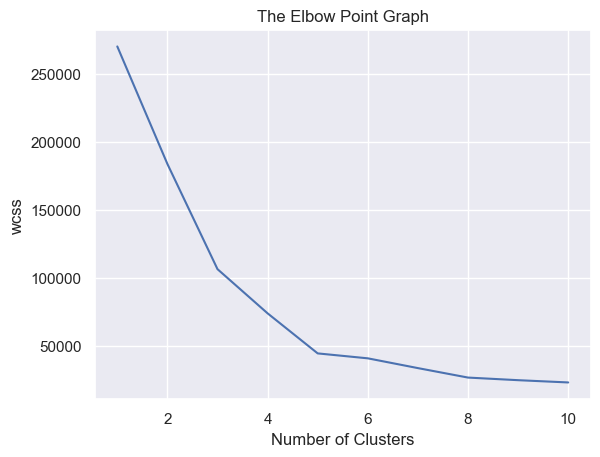

In [13]:
sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

#### Cette ligne initialise un modèle K-Means qui divise les données en 5 clusters en utilisant la méthode k-means++ pour de meilleurs centres initiaux. Elle définit également un état aléatoire fixe afin d’assurer des résultats cohérents à chaque exécution.

In [14]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

#### Cette ligne ajuste le modèle K-Means aux données X et prédit directement les étiquettes des clusters, en stockant dans Y le cluster attribué à chaque point de données.

In [15]:
Y = kmeans.fit_predict(X)

In [16]:
Y

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

### Visualiser les groupes avec des couleurs différentes.

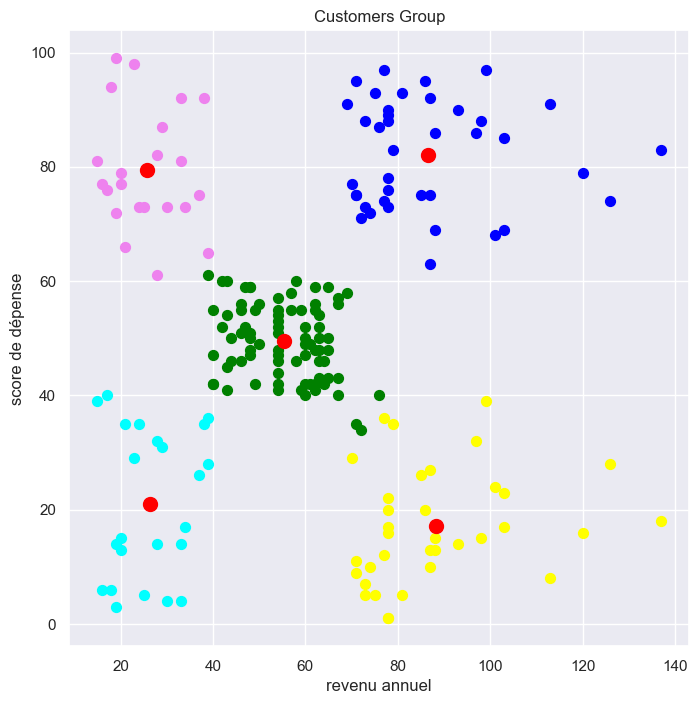

In [17]:
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], c='green', s=50, label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], c='blue', s=50, label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], c='yellow', s=50, label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], c='cyan', s=50, label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], c='violet', s=50, label='Cluster 5')
# Afficher les centres des clusters pour mieux comprendre leur position.
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=100, label='Centriods')
plt.title('Customers Group')
plt.xlabel('revenu annuel')
plt.ylabel('score de dépense')
plt.show()





# Le graphique présente les résultats du clustering K-Means,
# où les clients sont segmentés en cinq groupes distincts en fonction de leur revenu annuel et de leur score de dépense.
# Chaque couleur représente un cluster de clients ayant un comportement similaire, tandis que les points rouges indiquent les centroïdes.

# Les clusters peuvent être interprétés comme suit :
# le cluster rose représente les clients à faible revenu mais à forte dépense,
# le cluster cyan représente les clients à faible revenu et à faible dépense,
# le cluster vert représente les clients à revenu moyen et à dépense moyenne,
# le cluster bleu représente les clients à revenu élevé et à forte dépense (clients premium),
# et le cluster jaune représente les clients à revenu élevé mais à faible dépense.
